<a href="https://colab.research.google.com/github/arun-c-s-07/AI-ML-internship/blob/main/day_6_tumour(cnn).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Found 253 files belonging to 2 classes.
Using 203 files for training.
Found 253 files belonging to 2 classes.
Using 50 files for validation.
Classes: ['no', 'yes']
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 885ms/step - accuracy: 0.6502 - loss: 0.6516 - val_accuracy: 0.7800 - val_loss: 0.5356
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 895ms/step - accuracy: 0.7586 - loss: 0.5167 - val_accuracy: 0.8000 - val_loss: 0.5675
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7980 - loss: 0.4754 - val_accuracy: 0.8000 - val_loss: 0.5496
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 857ms/step - accuracy: 0.8128 - loss: 0.4586 - val_accuracy: 0.8000 - val_loss: 0.5974
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 884ms/step - accuracy: 0.8177 - loss: 0.4110 - val_accuracy: 0.7800 - val_loss: 0.5970
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8473 - loss: 0.3445 - val_accuracy: 0.8000 - val_loss: 0.5355
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 859ms/step - accuracy: 0.8867 - loss: 0.2814 - val_accuracy: 0.8200 - val_loss: 0.7071
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 930ms/step - accuracy: 0.8818 - loss: 0.2841 - val_accuracy: 0.8600 - val_loss: 0.5570
Epoch 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 336ms/step


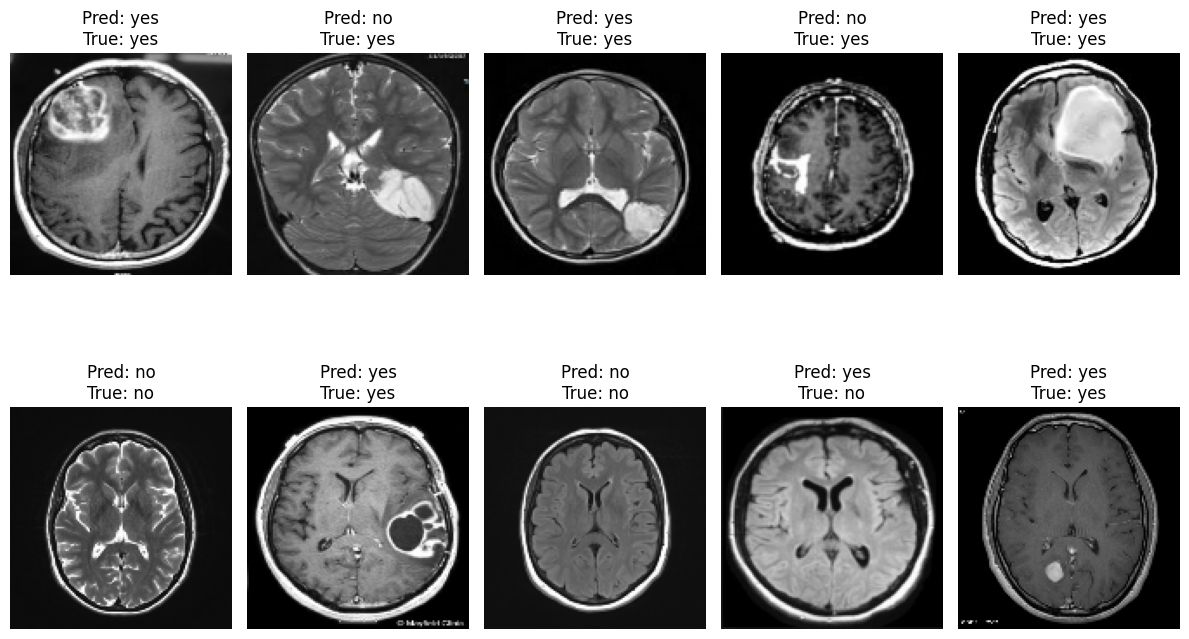

In [18]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import zipfile
import os

# Dataset path
dataset_path_unzipped_folder = "brain_tumor_dataset" # This is the folder created by unzipping
zip_file_path = "archive (21).zip"

# Check if the dataset directory exists, if not, try to extract it
if not os.path.exists(dataset_path_unzipped_folder):
    if os.path.exists(zip_file_path):
        print(f"Unzipping {zip_file_path}...")
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(".") # Extract to the current directory
        print("Unzipping complete.")
    else:
        print(f"Error: Dataset directory '{dataset_path_unzipped_folder}' and zip file '{zip_file_path}' not found.")
        print("Please upload the 'brain_tumor_dataset' folder or the 'archive (21).zip' file.")

# Define the root directory where the 'no' and 'yes' class folders reside
image_data_root_dir = os.path.join(dataset_path_unzipped_folder, dataset_path_unzipped_folder) # Corrected path

# Load images from folders
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_data_root_dir, # Use the corrected root directory
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    image_data_root_dir, # Use the corrected root directory
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=32
)

class_names = train_ds.class_names
print("Classes:", class_names)

# Normalize images
normalization_layer = keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# CNN Model
model = keras.Sequential([
    keras.layers.Conv2D(
        32, (3,3),
        activation='relu',
        input_shape=(128,128,3)
    ),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(128, activation='relu'),

    keras.layers.Dense(1, activation='sigmoid') # Corrected for binary classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy', # Corrected loss function for binary classification
    metrics=['accuracy']
)

# Train
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Evaluate
loss, acc = model.evaluate(val_ds)

print(f"\nValidation Accuracy: {acc:.4f}")

# Prediction on a few images
for images, labels in val_ds.take(1):
    predictions = model.predict(images)

    plt.figure(figsize=(12, 8)) # Increased figure size for better layout
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i].numpy())
        # Display predicted class name
        predicted_label = (predictions[i] > 0.5).astype(int) # Get binary prediction (0 or 1)
        predicted_class = class_names[predicted_label[0]] # Map to class name
        true_class = class_names[labels[i].numpy()]
        plt.title(f"Pred: {predicted_class}\nTrue: {true_class}")
        plt.axis("off")
    plt.tight_layout() # Added to prevent text overlapping
    plt.show()

In [19]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Flatten, Dense, Dropout

# Define image dimensions (from previous data loading step)
IMG_WIDTH, IMG_HEIGHT = 128, 128

# Load the VGG16 model with pre-trained ImageNet weights, excluding the top (classification) layers
base_model_vgg16 = VGG16(weights='imagenet', include_top=False, input_shape=(IMG_WIDTH, IMG_HEIGHT, 3))

# Freeze the layers of the pre-trained model
for layer in base_model_vgg16.layers:
    layer.trainable = False

# Create a new model on top of the pre-trained base
x = base_model_vgg16.output
x = Flatten()(x) # Flatten the output of the VGG16 base
x = Dense(256, activation='relu')(x) # Add a new dense layer
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(1, activation='sigmoid')(x) # Output layer for binary classification

transfer_model = Model(inputs=base_model_vgg16.input, outputs=predictions)

transfer_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

transfer_model.summary()
print("Transfer learning model (VGG16) built and compiled successfully.")

print("\nTraining the VGG16 transfer learning model...")
EPOCHS_TRANSFER = 15 # You can adjust this number

history_transfer = transfer_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER
)

loss_transfer, acc_transfer = transfer_model.evaluate(val_ds)

print(f"\nTransfer Model Validation Accuracy: {acc_transfer:.4f}")

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 16, 16, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,812,353 (64.13 MB)

 Trainable params: 2,097,665 (8.00 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

Transfer learning model (VGG16) built and compiled successfully.

Training the VGG16 transfer learning model...
Epoch 1/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 52s 7s/step - accuracy: 0.6502 - loss: 0.8461 - val_accuracy: 0.7800 - val_loss: 0.4382
Epoch 2/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 48s 7s/step - accuracy: 0.7734 - loss: 0.4224 - val_accuracy: 0.8200 - val_loss: 0.4006
Epoch 3/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.8177 - loss: 0.4092 - val_accuracy: 0.9200 - val_loss: 0.3546
Epoch 4/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 80s 7s/step - accuracy: 0.8276 - loss: 0.3491 - val_accuracy: 0.9400 - val_loss: 0.3269
Epoch 5/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 84s 7s/step - accuracy: 0.8867 - loss: 0.2483 - val_accuracy: 0.8800 - val_loss: 0.3179
Epoch 6/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.9310 - loss: 0.2033 - val_accuracy: 0.9200 - val_loss: 0.2887
Epoch 7/15
7/7 ━━━━━━━━━━━━━━━━━━━━ 49s 7s/step - accuracy: 0.9310 - loss: 0.1871 - val_accuracy: 0.9200 - val_loss: 0.2726
Epoch 8/15
7/7 ━━━━━

In [20]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_image(model_to_use, img_path, img_width, img_height, class_names):
    img = image.load_img(img_path, target_size=(img_width, img_height))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Create a batch
    img_array /= 255.0 # Rescale as the model was trained with rescaled inputs

    prediction = model_to_use.predict(img_array)

    # For binary classification with sigmoid output
    predicted_label_index = (prediction[0] > 0.5).astype(int)[0]
    predicted_class_name = class_names[predicted_label_index]

    return predicted_class_name

print("predict_image function defined.")

predict_image function defined.


True class: no


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 636ms/step
Predicted class using transfer_model: no


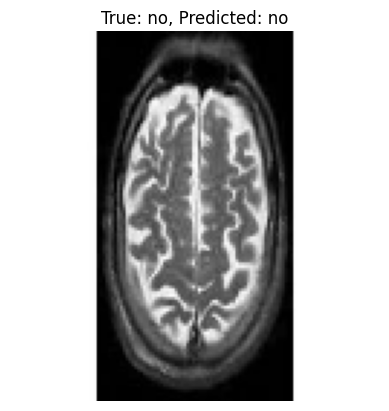

In [21]:
# Get one batch from the validation dataset for demonstration
for images, labels in val_ds.take(1):
    # Take the first image from the batch
    sample_image_array = images[0].numpy() # This is already normalized
    sample_true_label = labels[0].numpy()

    # To use predict_image, we need a path, so we'll save this image temporarily
    from PIL import Image
    temp_demon_path = '/content/temp_sample_image.png'
    Image.fromarray((sample_image_array * 255).astype(np.uint8)).save(temp_demon_path)

    print(f"True class: {class_names[sample_true_label]}")
    prediction_result = predict_image(transfer_model, temp_demon_path, IMG_WIDTH, IMG_HEIGHT, class_names)
    print(f"Predicted class using transfer_model: {prediction_result}")

    # Clean up the temporary image
    os.remove(temp_demon_path)

    # Display the image
    plt.imshow(sample_image_array)
    plt.title(f"True: {class_names[sample_true_label]}, Predicted: {prediction_result}")
    plt.axis('off')
    plt.show()
    break # Only take one image for demonstration